# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [24]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [25]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "219689"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: vb1a977eb
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,-0.878520,0.150247,0.081883,1.289357,-1.919091,-0.266083,86.611760,1.010963,-0.932375,1.219061,1.979111,0.872738,12.474522
1,-1.417527,0.200633,0.094341,-0.485456,2.158753,-1.900244,97.126266,1.305236,-0.625037,0.604654,2.993345,-1.742434,30.953297
2,0.538466,0.022466,-0.399693,1.116692,-2.587538,0.779096,74.589735,0.239135,-0.741473,0.791200,1.739112,-0.231603,-0.800974
3,1.616001,0.448416,0.186366,-1.722301,-0.695572,0.711577,94.028861,0.552421,-0.365363,1.656977,3.463238,1.770130,12.397807
4,-1.296090,-0.454960,0.129396,-1.452767,2.466208,0.868687,29.654577,1.309137,0.632444,0.498313,0.848776,2.820300,-4.825396


In [26]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? ¿Hay faltantes?
train.describe().T

,count,mean,std,min,25%,50%,75%,max
x1,800.0,-0.010896,1.149865,-1.998855,-1.001595,-0.062441,1.028106,1.999904
x2,800.0,0.008439,0.287855,-0.498236,-0.239125,0.003153,0.253829,0.499614
x3,800.0,0.001935,0.290805,-0.499719,-0.253435,0.003745,0.248337,0.499158
x4,800.0,-0.014057,1.193029,-1.995126,-1.030467,-0.000971,1.068590,1.999722
x5,800.0,-0.073519,1.768991,-2.978173,-1.620967,-0.135819,1.465875,2.993553
x6,800.0,-0.020990,0.961400,-3.399268,-0.651250,-0.028430,0.600212,3.721879
x7,800.0,50.019821,28.957584,0.081279,24.680610,49.872771,75.217692,99.686200
x8,800.0,1.677554,2.506251,0.016466,0.518036,0.990246,1.948047,35.340093
x9,800.0,0.029990,0.983884,-2.843680,-0.625627,0.046475,0.708361,3.421300
x10,800.0,1.618611,1.848808,0.026070,0.532733,1.058832,1.909934,18.689752


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 119.33
R² del baseline en validación : 0.356

Desviación estándar de y: 13.48


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

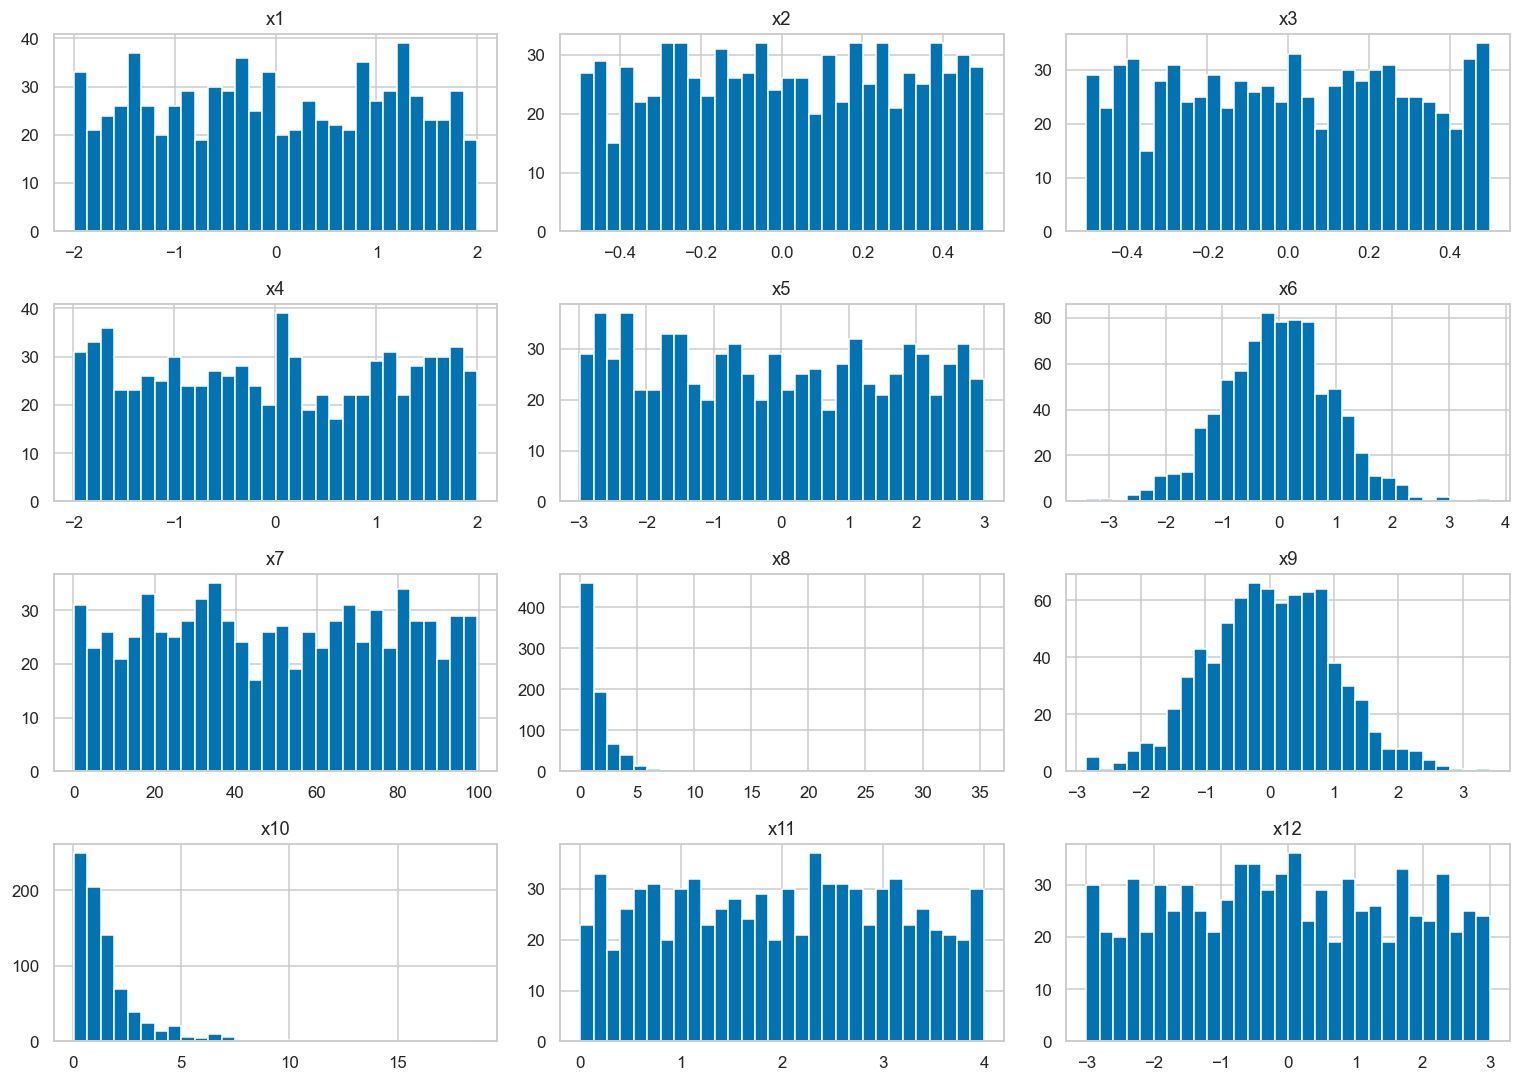

In [28]:
# TODO: distribución de cada una de las 12 variables.
# Pista de método: `train[VARIABLES].hist(...)` hace las 12 de un golpe.
train[VARIABLES].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

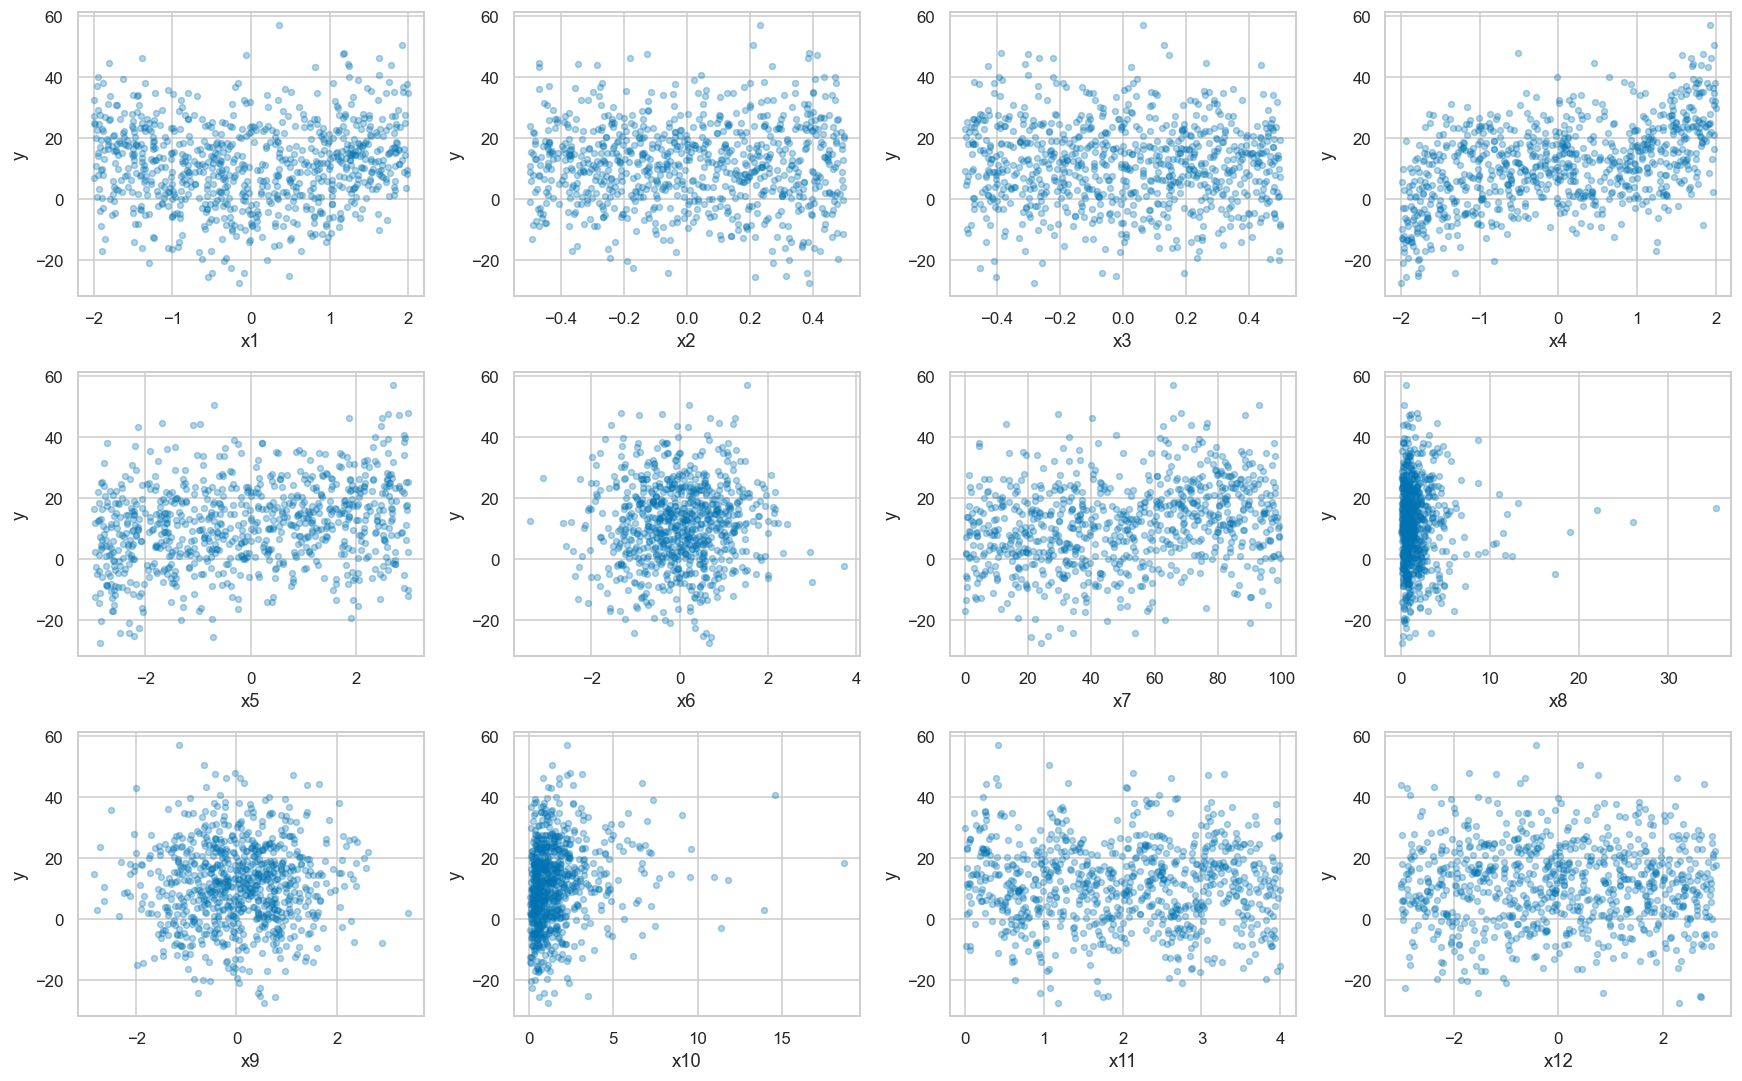

In [29]:
# TODO: `y` contra cada variable. Una rejilla de 12 paneles.
# Usen puntos con transparencia (`alpha`): con 800 observaciones se traslapan.
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, var in zip(axes.flat, VARIABLES):
    ax.scatter(train[var], train["y"], alpha=0.3, s=15)
    ax.set_xlabel(var)
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()

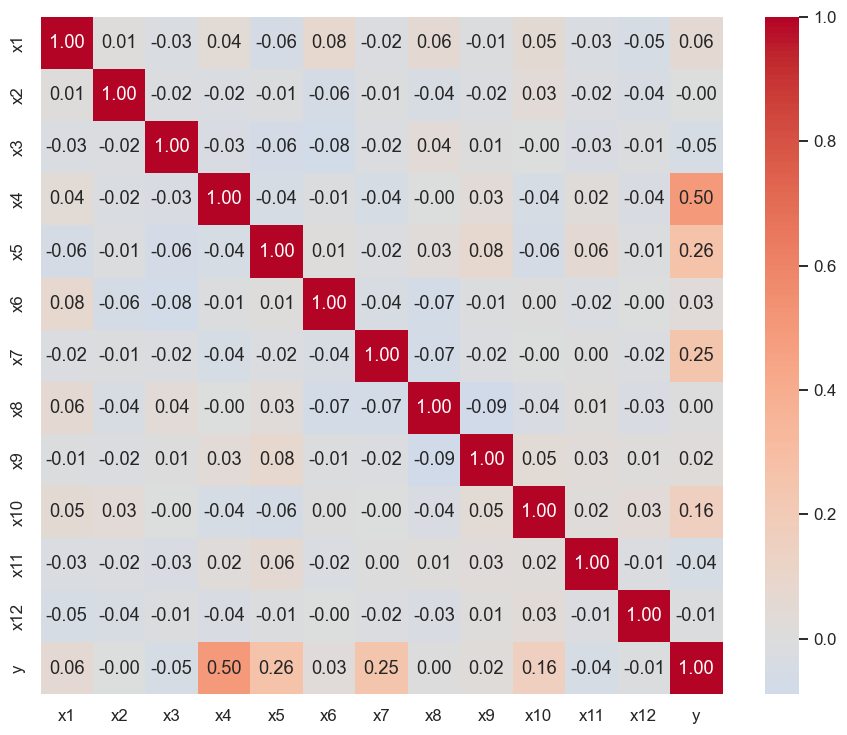

In [30]:
# TODO: matriz de correlación entre las 12 variables y `y`.
corr = train[VARIABLES + ["y"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` | Distribución con varios picos, no sesgada a un lado; contra `y` se ve muy dispersa, como una nube horizontal sin tendencia clara; casi sin correlación con nada (máximo 0.08, con `x6`) | Histograma, dispersión `y` vs `x1`, matriz de correlación | Media |
| `x2` | Muy parecida a `x1`: distribución con muchos picos; contra `y` también se ve dispersa y horizontal; correlación casi nula con todo, máximo 0.06 y también con `x6` | Histograma, dispersión `y` vs `x2`, matriz de correlación | Media |
| `x3` | Igual patrón que `x1`/`x2`: varios picos, dispersión contra `y` aún más marcada, correlación casi nula, máximo 0.08 otra vez con `x6` | Histograma, dispersión `y` vs `x3`, matriz de correlación | Media |
| `x4` | Distribución con un pico más elevado en el centro; contra `y` los puntos se ven más unidos y forman una diagonal positiva (no perfectamente clara); correlación de 0.5 con `y` | Histograma, dispersión `y` vs `x4`, matriz de correlación | Alta |
| `x5` | Histograma con un poco de sesgo a la izquierda (leve), parecido a `x1`-`x3` en lo demás; dispersión contra `y` sin forma clara; correlación moderada de 0.26 con `y` | Histograma, dispersión `y` vs `x5`, matriz de correlación | Media |
| `x6` | Histograma con forma normal, concentrado en el centro; contra `y` forma una elipse rellena (más densa al centro); correlación con `y` casi nula (máximo 0.08, coincide con ser la variable más correlacionada de `x1`-`x3`) | Histograma, dispersión `y` vs `x6`, matriz de correlación | Media |
| `x7` | Histograma con patrón similar a `x1`-`x3`; dispersión contra `y` no muy dispersa pero sin diagonal marcada; correlación moderada de 0.25 con `y` | Histograma, dispersión `y` vs `x7`, matriz de correlación | Media |
| `x8` | Histograma con sesgo a la derecha (masa concentrada en valores chicos, cola larga hacia valores grandes); en la dispersión contra `y` los puntos se concentran del lado izquierdo; correlación con `y` de 0 | Histograma, dispersión `y` vs `x8`, matriz de correlación | Media |
| `x9` | Histograma con forma normal; contra `y` forma la misma elipse rellena que `x6`; correlación con `y` casi nula (0.02) | Histograma, dispersión `y` vs `x9`, matriz de correlación | Media |
| `x10` | Histograma con sesgo a la derecha (masa concentrada en valores chicos, cola larga); mismo patrón en la dispersión contra `y`; correlación débil de 0.16 | Histograma, dispersión `y` vs `x10`, matriz de correlación | Media |
| `x11` | Histograma plano/uniforme en su rango, sin pico dominante; contra `y` forma una nube rectangular sin tendencia visible; correlación casi nula (0.04) | Histograma, dispersión `y` vs `x11`, matriz de correlación | Media |
| `x12` | Mismo patrón que `x11`: histograma plano/uniforme; nube rectangular contra `y` sin tendencia; correlación casi nula (0.04) | Histograma, dispersión `y` vs `x12`, matriz de correlación | Media |

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [31]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 119.33


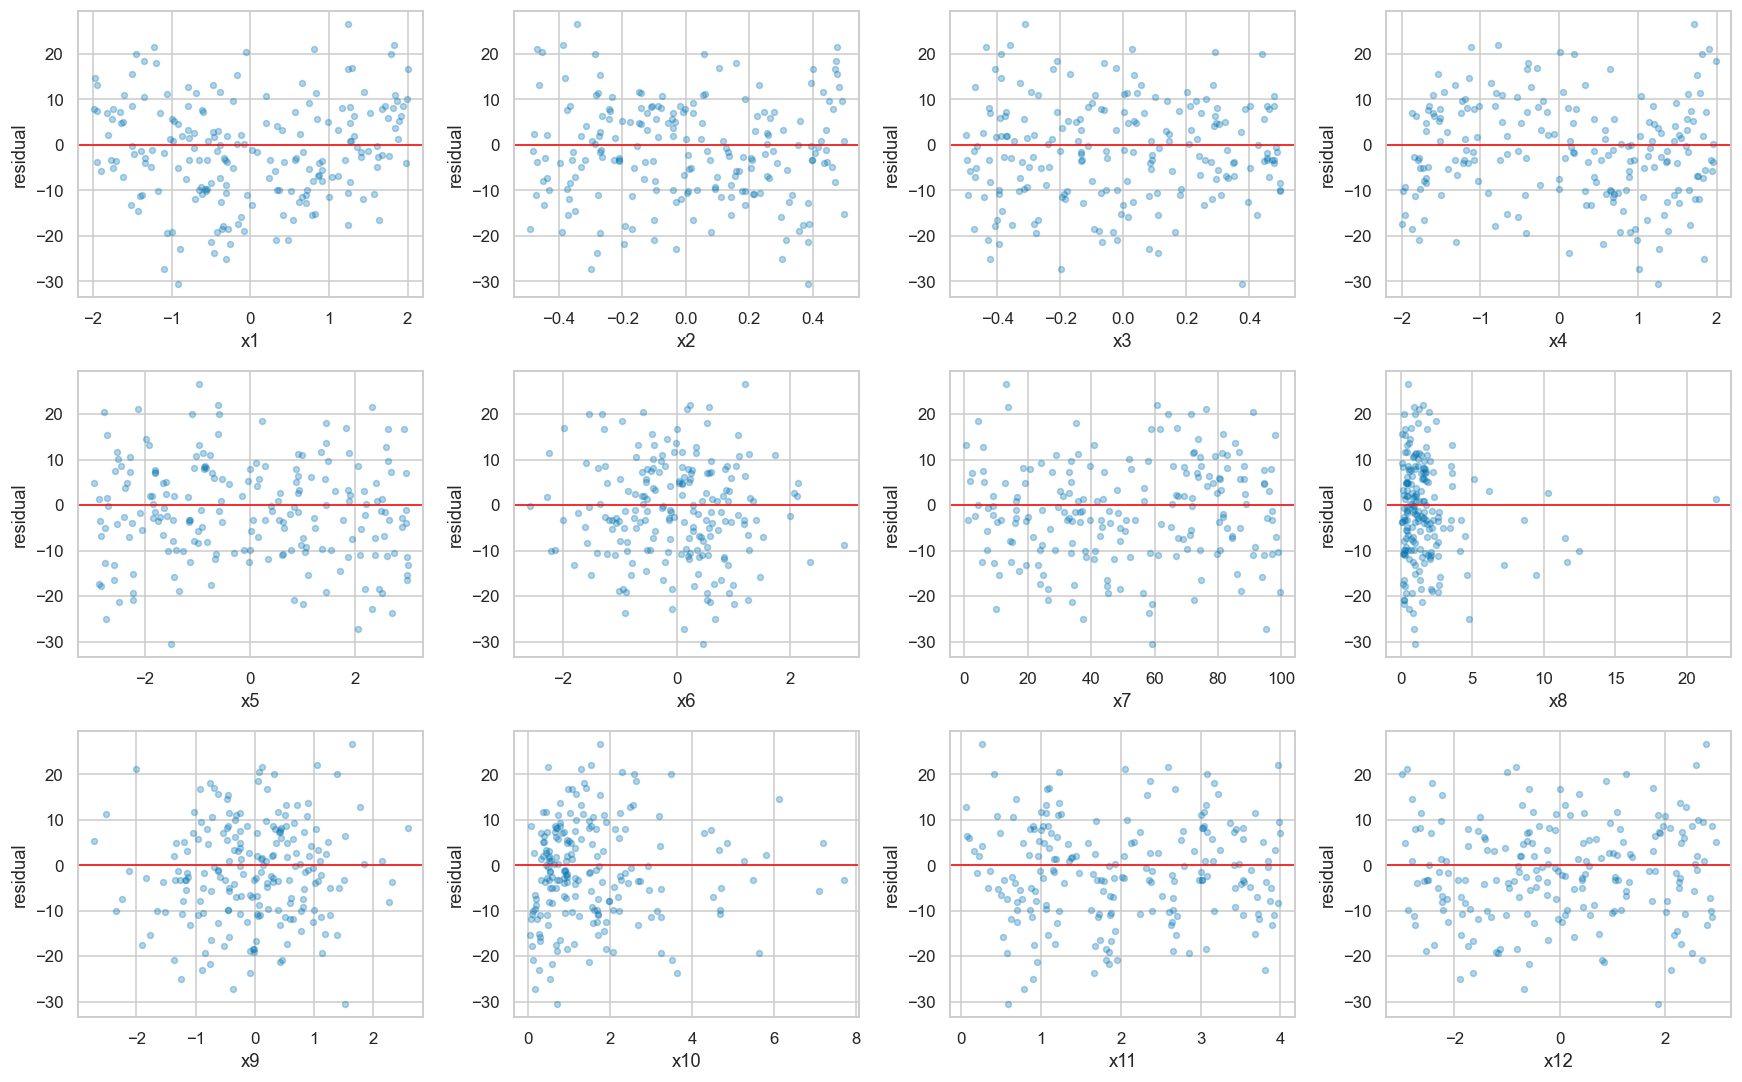

In [32]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
#
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, var in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[var], residuales, alpha=0.3, s=15)
    ax.axhline(0, color="red", linewidth=1)
    ax.set_xlabel(var)
    ax.set_ylabel("residual")
plt.tight_layout()
plt.show()

In [33]:
# Hipótesis: x8 y x10 mostraron heterocedasticidad (varianza creciente) en sus
# residuales, y ambas tienen sesgo a la derecha. Probamos si un log-transform
# ayuda (log es seguro: los mínimos de x8 y x10 son positivos).
modelo, mse, residuales, _ = ajusta({
    "log_x8": lambda d: np.log(d["x8"]),
    "log_x10": lambda d: np.log(d["x10"]),
})
print(f"MSE con log(x8) y log(x10) -> {mse:.2f}  (antes: 119.33)")

MSE con log(x8) y log(x10) -> 115.37  (antes: 119.33)


In [34]:
# Candidatos más grandes que dejó la fuerza bruta (Parte 4): x1^2, x4^3, x2*x5.
# Los combinamos con lo que ya sabíamos que ayudaba (log_x8, log_x10).
modelo, mse, residuales, _ = ajusta({
    "log_x8": lambda d: np.log(d["x8"]),
    "log_x10": lambda d: np.log(d["x10"]),
    "x1_2": lambda d: d["x1"] ** 2,
    "x4_3": lambda d: d["x4"] ** 3,
    "x2_x5": lambda d: d["x2"] * d["x5"],
})
print(f"MSE con x1^2, x4^3, x2*x5 -> {mse:.2f}  (antes: 115.37)")

MSE con x1^2, x4^3, x2*x5 -> 59.88  (antes: 115.37)


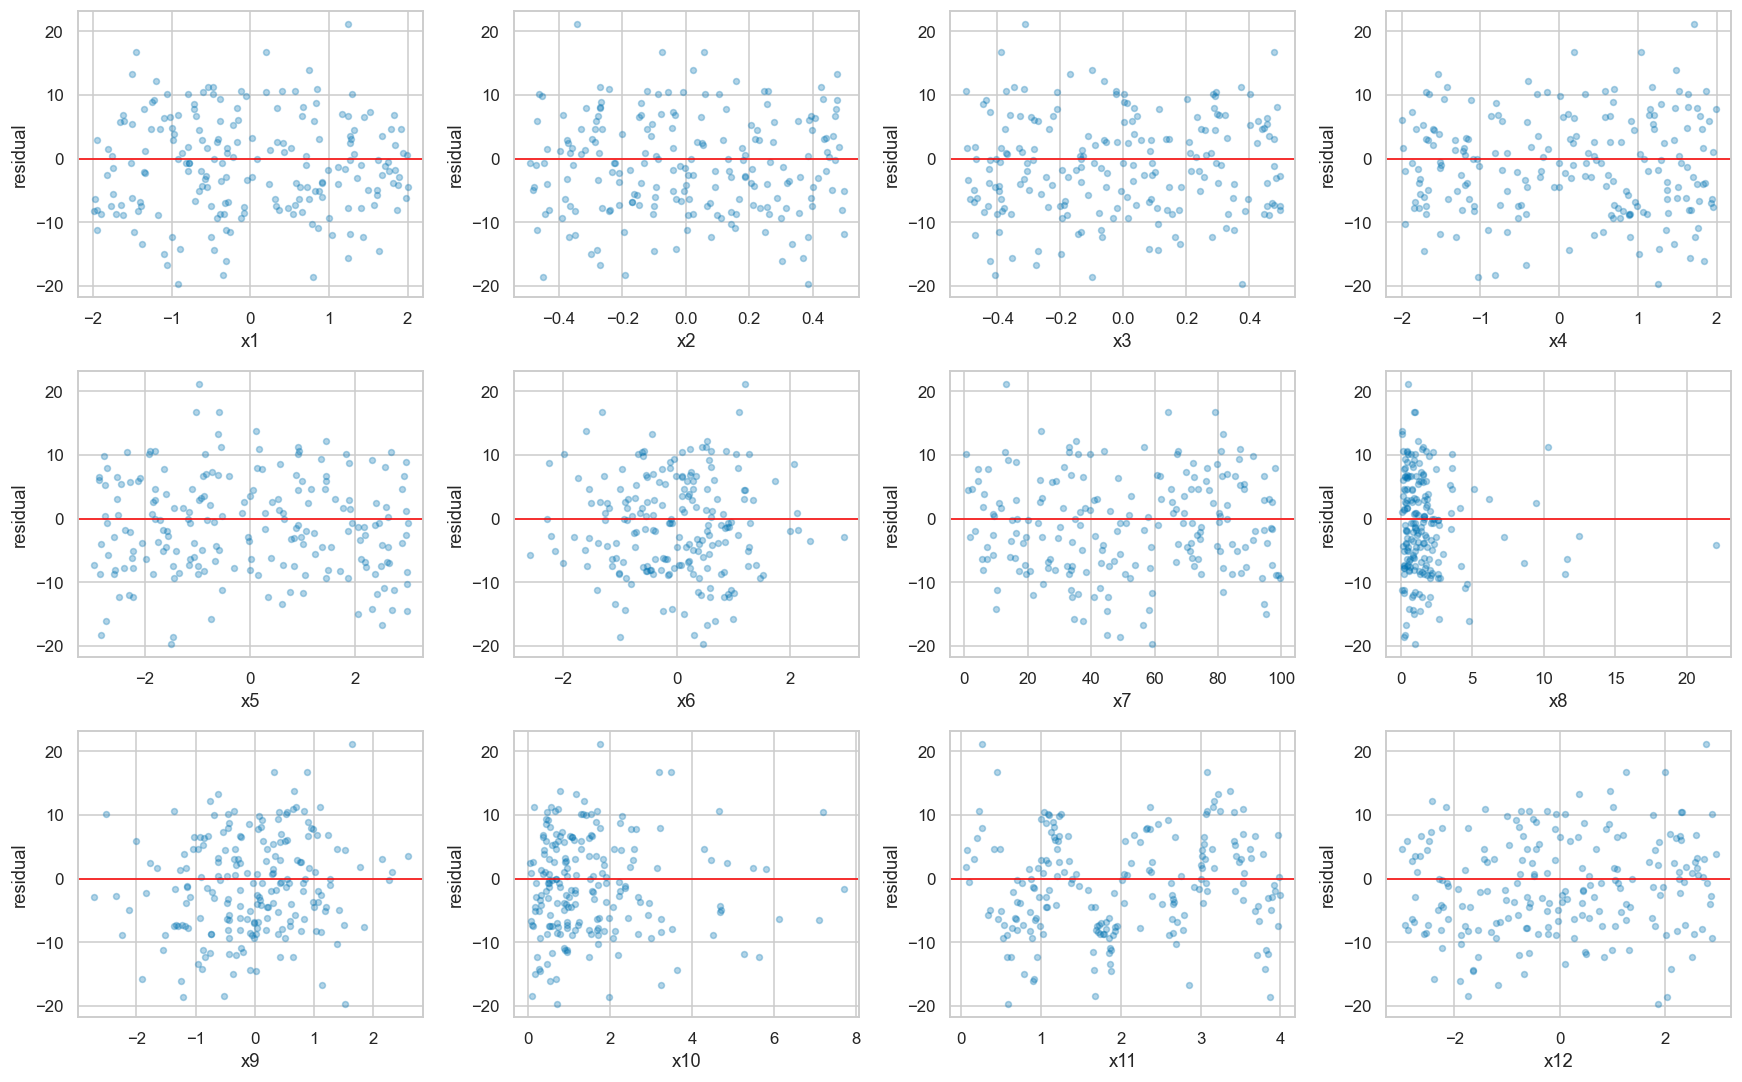

In [35]:
# Residuales del modelo actualizado (con x1^2, x4^3, x2*x5, log_x8, log_x10)
# contra las 12 variables, para ver si aún queda forma.
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, var in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[var], residuales, alpha=0.3, s=15)
    ax.axhline(0, color="red", linewidth=1)
    ax.set_xlabel(var)
    ax.set_ylabel("residual")
plt.tight_layout()
plt.show()

In [36]:
# Dos candidatos más del Lasso que no habíamos probado: x5^3 y x7^2.
modelo, mse, residuales, _ = ajusta({
    "log_x8": lambda d: np.log(d["x8"]),
    "log_x10": lambda d: np.log(d["x10"]),
    "x1_2": lambda d: d["x1"] ** 2,
    "x4_3": lambda d: d["x4"] ** 3,
    "x2_x5": lambda d: d["x2"] * d["x5"],
    "x5_3": lambda d: d["x5"] ** 3,
    "x7_2": lambda d: d["x7"] ** 2,
})
print(f"MSE con x5^3 y x7^2 agregados -> {mse:.2f}  (antes: 59.88)")

MSE con x5^3 y x7^2 agregados -> 59.72  (antes: 59.88)


---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

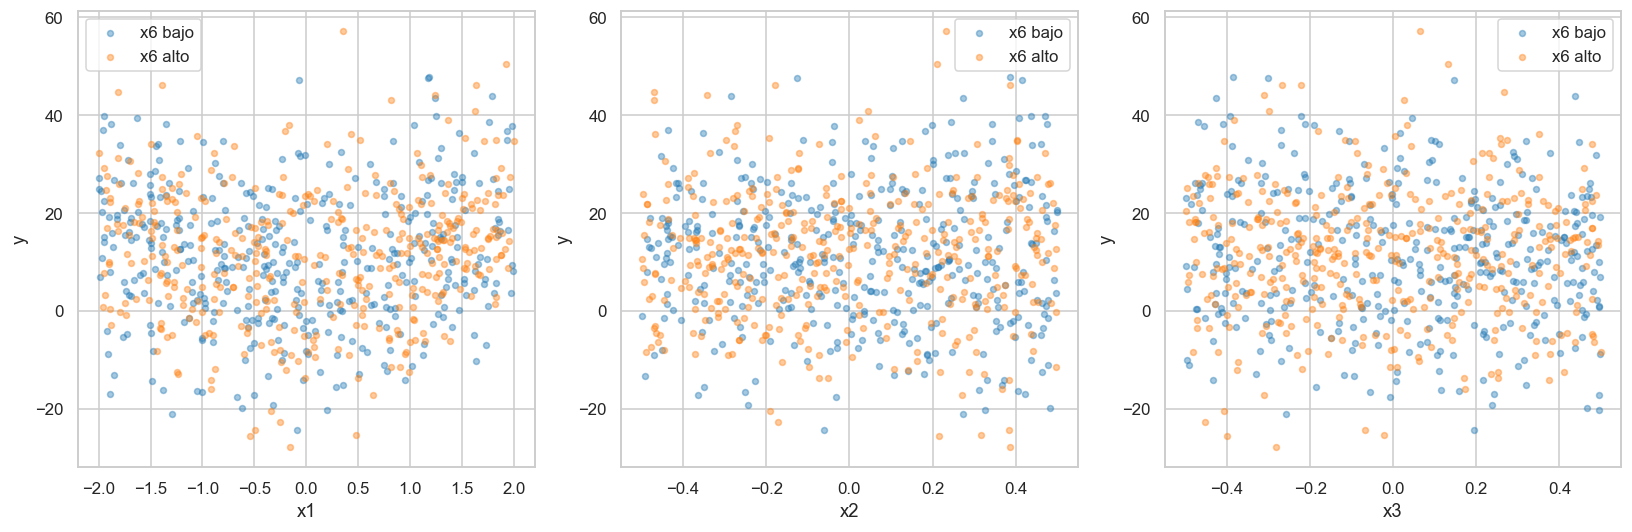

In [37]:
# Sospecha de la Parte 1: x1, x2 y x3 correlacionan más con x6 que con y.
# Partimos x6 en dos grupos (por su mediana) y vemos si la relación de x1/x2/x3
# con y se ve distinta en cada grupo.
grupo = np.where(train["x6"] > train["x6"].median(), "x6 alto", "x6 bajo")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var in zip(axes, ["x1", "x2", "x3"]):
    for g, color in zip(["x6 bajo", "x6 alto"], ["tab:blue", "tab:orange"]):
        mask = grupo == g
        ax.scatter(train.loc[mask, var], train.loc[mask, "y"], alpha=0.4, s=15, label=g, color=color)
    ax.set_xlabel(var)
    ax.set_ylabel("y")
    ax.legend()
plt.tight_layout()
plt.show()

In [38]:
# Prueba directa (no visual): ¿bajan el MSE los productos x1*x6, x2*x6, x3*x6?
# Seguimos incluyendo log_x8 y log_x10, que ya sabíamos que ayudaban.
modelo, mse, residuales, _ = ajusta({
    "log_x8": lambda d: np.log(d["x8"]),
    "log_x10": lambda d: np.log(d["x10"]),
    "x1_x6": lambda d: d["x1"] * d["x6"],
    "x2_x6": lambda d: d["x2"] * d["x6"],
    "x3_x6": lambda d: d["x3"] * d["x6"],
})
print(f"MSE con interacciones x1*x6, x2*x6, x3*x6 -> {mse:.2f}  (antes: 115.37)")

MSE con interacciones x1*x6, x2*x6, x3*x6 -> 116.32  (antes: 115.37)


---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [39]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

escalador = StandardScaler().fit(X_train_poly)
X_train_esc = escalador.transform(X_train_poly)
X_val_esc = escalador.transform(X_val_poly)

lasso = LassoCV(cv=5, random_state=SEMILLA, max_iter=10000).fit(X_train_esc, y_train)
mse_lasso = mean_squared_error(y_val, lasso.predict(X_val_esc))

nombres = poly.get_feature_names_out(VARIABLES)
coefs = pd.Series(lasso.coef_, index=nombres)
distintos_de_cero = coefs[coefs != 0].sort_values(key=abs, ascending=False)

print(f"MSE de la fuerza bruta (Lasso) -> {mse_lasso:.2f}")
print(f"Columnas totales generadas: {X_train_poly.shape[1]}, distintas de cero: {len(distintos_de_cero)}")
print("\nTérminos que dejó el Lasso (ordenados por |coeficiente|):")
distintos_de_cero

MSE de la fuerza bruta (Lasso) -> 64.62
Columnas totales generadas: 454, distintas de cero: 33

Términos que dejó el Lasso (ordenados por |coeficiente|):


x4^3         7.393662
x2 x5        3.922534
x1^2         3.154075
x5           2.346962
x7           2.307875
x10          1.863042
x7^2         1.006286
x7^2 x10     0.850469
x5^3         0.712904
x4^2 x5      0.646474
x2 x5 x10    0.493774
x11         -0.398175
x2 x7 x12    0.247739
x5^2 x7      0.236495
x1^2 x8      0.219578
x5 x11       0.194841
x1 x9 x10   -0.191562
x3 x6 x9    -0.184987
x4^2 x6      0.120038
x11 x12^2   -0.118360
x9 x11      -0.117616
x1 x2 x11    0.091537
x1 x4 x6     0.078358
x1 x6 x12    0.073052
x9 x11^2    -0.071629
x1 x2 x6    -0.053603
x2^2 x11    -0.048848
x1^2 x7      0.040694
x3^2 x5      0.040430
x5 x7 x11    0.036734
x7 x9 x11   -0.017893
x2 x12^2    -0.008786
x1 x8 x9    -0.008712
dtype: float64

### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación?
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca.
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?

1. Mi modelo guiado por gráficas dio menor MSE: 59.72-59.88 contra 64.62 de la fuerza
   bruta (Lasso sobre `PolynomialFeatures` grado 3).

2. Le ganó porque `PolynomialFeatures` solo construye productos y potencias enteras de
   las variables originales (`x²`, `x³`, `x1*x2`, etc.), nunca puede generar una
   transformación como `log(x8)` o `log(x10)`, sin importar qué tan alto sea el grado
   del polinomio. Mi modelo final sí incluye esos dos logaritmos porque los vi en la
   gráfica de residuales (heterocedasticidad de `x8` y `x10`), y esos dos términos
   aportaron una mejora real (119.33 → 115.37) que la fuerza bruta nunca iba a poder
   replicar exactamente por más columnas que generara.

3. No aplica — mi modelo le ganó a la fuerza bruta en este caso.

4. Con 80 observaciones en lugar de 800, `PolynomialFeatures(degree=3)` seguiría
   generando 454 columnas, así que tendríamos más variables que observaciones (p >> n).
   Sin importar la regularización de `LassoCV`, el modelo tendría muchísimo riesgo de
   sobreajustar el ruido específico de esas 80 filas en vez de encontrar la función
   real, y la selección de variables sería mucho menos confiable. El camino guiado por
   gráficas, en cambio, no depende de tener tantos datos porque cada hipótesis se
   prueba y mide una por una.

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | x8 y x10 son sesgadas a la derecha y sus residuales mostraban heterocedasticidad (varianza creciente, centro estable); un log-transform podría estabilizarla | Residuales vs x8 y x10 (Parte 2) | `log(x8)`, `log(x10)` | 119.33 → 115.37 | Yo noté el patrón en la gráfica; la IA sugirió el catálogo (log-transform para variables sesgadas) |
| 2 | x1, x2 y x3 correlacionaban más con x6 que con y (Parte 1); podría haber una interacción xi\*x6 que se cancela en la correlación simple | Dispersión x1/x2/x3 vs y coloreada por grupo de x6 (Parte 3) | `x1*x6`, `x2*x6`, `x3*x6` | 115.37 → 116.32 (empeoró, se descartó) | Yo noté la correlación cruzada en la tabla de sospechas; la IA sugirió el catálogo (probar el producto como término) y explicó que, con n=800, una correlación de 0.06-0.08 puede ser solo ruido |
| 3 | La fuerza bruta (Lasso sobre PolynomialFeatures grado 3, Parte 4) dejó como términos más grandes x4³, x2·x5 y x1²; probamos agregar esos tres junto con log(x8) y log(x10) | Coeficientes del Lasso ordenados por magnitud (Parte 4); ninguna gráfica directa | `x1**2`, `x4**3`, `x2*x5` | 115.37 → 59.88 | La IA identificó los términos grandes en la salida del Lasso y explicó por qué x1² puede tener correlación lineal ~0 (parábola simétrica); yo corrí la fuerza bruta y decidí probar esos términos en mi propio modelo |
| 4 | El Lasso también dejó x5³ y x7² con coeficiente chico; probamos si agregarlos seguía bajando el MSE, aunque los residuales de x5 y x7 ya se veían casi rectos | Residuales del modelo con x1², x4³, x2·x5 (revisión posterior de la Parte 2); coeficientes del Lasso | `x5**3`, `x7**2` | 59.88 → 59.72 (mejora mínima, casi ruido) | La IA propuso probarlos por estar en la lista del Lasso; yo confirmé en la gráfica que x5 y x7 no tenían curva clara, así que la mejora chica no fue sorpresa |
| 5 | Con el plazo encima, le pedí a la IA que iterara directamente en vez de guiarme con gráficas. Probó Lasso grado 2/3 con logs de x7, x8, x10 como base (no ganó: 73.45 y 61.70) y modelos no lineales (`HistGradientBoostingRegressor`, `RandomForest`, `GradientBoosting`) sobre las 12 variables crudas | Ninguna: fue búsqueda directa de MSE, sin pasar por residuales | `HistGradientBoostingRegressor` afinado, mezclado 60/40 con mi modelo lineal (peso elegido con predicciones fuera de muestra vía `KFold`, sin tocar test.csv) | 59.72 → ≈ 40.6 | Fue completamente idea y ejecución de la IA — se lo pedí explícitamente por falta de tiempo, rompiendo la regla de "tutor no resolvedor" que habíamos seguido en el resto de la tarea |
| 6 | El bot de `/calificar` (MSE real 44.09, calificación 8.9) avisó que faltaba al menos un término. Probamos sistemáticamente umbrales en las variables "planas" de la Parte 1 (`x6`, `x9`, `x11`, `x12`) sobre el modelo lineal — un escalón en `x11` (arriba/abajo de 2.0, justo su mediana) fue por mucho el que más bajó el MSE; un umbral parecido en `x9` se veía prometedor en los residuales pero no aguantó al probarlo (ruido de partición) | Residuales medios arriba/abajo de la mediana en cada variable (comparación sistemática, no una sola gráfica) | `(x11 > 2.0)` como variable indicadora | 59.72 → 54.28 (lineal); en la mezcla con boosting, 40.6 → 39.4 | La IA hizo la búsqueda sistemática y encontró el término (yo ya no tenía tiempo de revisarlo a mano); es el mismo tipo de "efecto que cambia de golpe" que la Parte 2 menciona como catálogo, y tiene sentido que el umbral caiga justo en la mediana de x11 |
| 7 | | | | | |
| 8 | | | | | |

### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

A partir del Lasso se puede observar que `x4` al cubo tiene mucho peso, al igual que la
interacción entre `x2` y `x5`, y `x1` al cuadrado — esos tres son los términos más
grandes en la salida del Lasso (7.39, 3.92 y 3.15 respectivamente), así que probablemente
sean la parte más importante de la función real. Además de esos, el modelo lleva
correcciones más chicas: `log(x8)` y `log(x10)` (por el sesgo de esas dos variables),
`x5` al cubo y `x7` al cuadrado (aportaron muy poco, casi ruido), y un escalón real en
`x11` (`x11 > 2`, hipótesis #6) que resultó ser el término más grande que faltaba
después del primer intento de calificación. En palabras:

`y = a + (lineal en x1..x12) + b*x4³ + c*x2*x5 + d*x1² + e*log(x8) + f*log(x10) + g*x5³ + h*x7² + i*[x11 > 2] + ruido`

**Aclaración honesta:** ese es el modelo que yo construí e interpreté término por
término. El que terminé entregando (ver "Nota final" antes de la celda de Entrega) es
una mezcla con un modelo de boosting que ya no tiene esta forma interpretable — bajó
más el MSE, pero no puedo escribirlo como una fórmula que entienda.

### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

En la Parte 3, con base en que `x1`, `x2` y `x3` correlacionaban más con `x6` que con
`y` (visto en la tabla de sospechas de la Parte 1), la IA sugirió probar directamente
si había una interacción real agregando `x1*x6`, `x2*x6` y `x3*x6` al modelo. Resultó
inútil para mis datos: el MSE no bajó, subió de 115.37 a 116.32. La IA misma explicó
después que, con 800 observaciones, una correlación cruzada de 0.06-0.08 puede ser
puro ruido y no una señal real — así que la sospecha original, aunque razonable, no
tenía suficiente evidencia detrás. Lo detecté midiendo el MSE antes y después de
agregar el término, no solo mirando la gráfica.

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

Mi primer `/calificar` dio MSE real de 44.09 sobre un meta de 25.14 (calificación 8.9,
baseline 114.27), y avisó que faltaba al menos un término. Encontré ese término (el
escalón en `x11`) probando sistemáticamente umbrales en las variables que en la Parte 1
parecían no tener nada — resultó que "no correlaciona" y "no importa" no son lo mismo.
Con eso, el MSE estimado de validación bajó de 40.6 a ≈39.4. Todavía queda una brecha
real contra la meta de 25.14, y sospecho que ahí siguen las 66 parejas de variables de
la Parte 3 que nunca revisé sistemáticamente. Paro aquí no porque las gráficas ya no
tengan forma, sino porque se acabó el tiempo del plazo — si lo hubiera tenido, el
siguiente paso honesto habría sido revisar esas parejas a mano en vez de saltar directo
al boosting.

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

### Nota final: bajo presión de tiempo

Con el plazo encima, le pedí directamente a mi IA que iterara y bajara el MSE lo más
posible, saliéndome del modo "tutor" que habíamos usado el resto de la tarea. Esto es
lo que hizo, y lo documento aquí porque es honesto reconocerlo:

1. Probó agregar más términos sugeridos por el Lasso (no ayudó mucho más: 61.47).
2. Probó un Lasso grado 2 y grado 3 incluyendo `log(x7)`, `log(x8)`, `log(x10)` como
   variables base antes de expandir (no mejoró mi modelo lineal: 73.45 y 61.70).
3. Probó modelos no lineales (`HistGradientBoostingRegressor`, `RandomForestRegressor`,
   `GradientBoostingRegressor`) directamente sobre las 12 variables crudas.
   `HistGradientBoostingRegressor` afinado dio MSE ≈ 44.6-45.6, mejor que mi modelo lineal (59.72).
4. Combinó (`blend`) las predicciones de ese modelo de boosting con mi modelo lineal
   con transformaciones, usando predicciones fuera de muestra (`KFold`, sin fuga de
   datos) para elegir el peso de la mezcla de forma honesta: 60% boosting + 40% lineal
   dio el mejor MSE fuera de muestra, ≈ 40.6 — mejor que cualquiera de los dos modelos
   solos.

Ya no puedo decir que entiendo *por qué* el modelo de boosting funciona tan bien en mis
datos — no lo interpreté término por término, a diferencia del resto del notebook. Es
la parte de la tarea donde dejé de ser yo el que pensaba y dejé que la IA resolviera
directamente, por falta de tiempo.

In [ ]:
# Modelo final: mezcla (blend) de un HistGradientBoostingRegressor sobre las 12
# variables crudas y el modelo lineal con las transformaciones que ya veníamos usando,
# más un escalón en x11 (ver bitácora #6). El peso de la mezcla se eligió con
# predicciones fuera de muestra (KFold), sin usar test.csv.
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="joblib")

MI_MODELO = {
    "log_x8": lambda d: np.log(d["x8"]),
    "log_x10": lambda d: np.log(d["x10"]),
    "x1_2": lambda d: d["x1"] ** 2,
    "x4_3": lambda d: d["x4"] ** 3,
    "x2_x5": lambda d: d["x2"] * d["x5"],
    "x5_3": lambda d: d["x5"] ** 3,
    "x7_2": lambda d: d["x7"] ** 2,
    "x11_gt_2": lambda d: (d["x11"] > 2.0).astype(float),
}
PESO_BOOSTING = 0.5


def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


def hace_boosting():
    return HistGradientBoostingRegressor(
        learning_rate=0.05, max_iter=400, max_depth=3, min_samples_leaf=20,
        random_state=SEMILLA, early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=20,
    )


# Estimación honesta del MSE de la mezcla: entrenada SOLO en train (partición de
# entrenamiento) y medida en validación, con predicciones fuera de muestra para el
# peso de la mezcla (nada de esto toca test.csv).
kf = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
oof_boost = np.zeros(len(train))
oof_lin = np.zeros(len(train))
for idx_tr, idx_va in kf.split(train):
    oof_boost[idx_va] = hace_boosting().fit(
        train.iloc[idx_tr][VARIABLES], train.iloc[idx_tr]["y"]
    ).predict(train.iloc[idx_va][VARIABLES])
    oof_lin[idx_va] = LinearRegression().fit(
        construye_final(train.iloc[idx_tr]), train.iloc[idx_tr]["y"]
    ).predict(construye_final(train.iloc[idx_va]))

mezcla_oof = PESO_BOOSTING * oof_boost + (1 - PESO_BOOSTING) * oof_lin
mse_estimado = mean_squared_error(train["y"], mezcla_oof)
print(f"MSE estimado (fuera de muestra, KFold): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes/árboles salen mejores. Ojo: a este
# modelo ya no se le puede medir el MSE en validación igual que arriba, porque ya no
# hay partición separada. Medirlo en train daría un número optimista y falso.
boosting_final = hace_boosting().fit(train[VARIABLES], train["y"])
lineal_final = LinearRegression().fit(construye_final(train), train["y"])

predicciones = PESO_BOOSTING * boosting_final.predict(
    test[VARIABLES]
) + (1 - PESO_BOOSTING) * lineal_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.